In [2]:
import numpy as np
import matplotlib.pyplot as pl
import matplotlib
import finufft
import time
import scipy.signal as ss
from scipy.interpolate import CubicSpline
from scipy import integrate

red = '#D60606'
blue = '#0083DE'
green = '#00BA75'
yellow = '#FFC61E'
purple = '#A433B3'
orange = '#FD882E'
color_arr = [red, blue, green, yellow, purple, orange]

mplparams = {
    'text.usetex': True,
    # 'axes.linewidth': 3,
    'lines.linewidth' : 1.5,
    'lines.markersize' : 10,
    'axes.grid': False,
    'axes.labelweight': 'normal',
    'font.family': 'DejaVu Sans',
    'font.size': 36,
    'figure.figsize': (15,10),
    'legend.fontsize': 26,
    'legend.handlelength' : 2,
    'legend.numpoints' : 1,
    'axes.grid' : True,
    'grid.alpha' : 0.9,
    'axes.prop_cycle': matplotlib.cycler(color=color_arr) 
}
matplotlib.rcParams.update(mplparams)

In [3]:
def f_calc(t, beta, f0):
    return f0*(1-8/3*beta*t)**(-3/8)

def df_calc(t, beta, f0):
    return f0*beta*(1-8/3*beta*t)**(-11/8)

def phi_calc(t, beta, f0):
    phi = -6*pi/5*f0*(1-8./3.*beta*t)**(5/8)/beta
#     phi = np.mod(phi,2*pi)
    return phi

def nufft(data, tau, bin_no):
    bins = np.arange(bin_no) - bin_no//2
    
    scale = (2*pi)/(tau[-1]-tau[0])
    tau *= scale
    start_diff = -pi-tau[0]
    tau += start_diff
    plan.setpts(x=np.array(tau))
    nufft_freq = -bins*scale/(2*pi)
#     nufft_amp = plan.execute(np.array(data.astype(complex)))
    nufft_amp = finufft.nufft1d1(np.array(tau), np.array(data.astype(complex)), bin_no)
    nufft_power = np.abs(nufft_amp/len(data))**2
    
    sort_idx = np.argsort(nufft_power)
    thresh_idx = np.searchsorted(nufft_power, np.array([0.01]), sorter=sort_idx)[0]
    return nufft_freq, nufft_power

In [4]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)


f_max = 200
f_signal = 4*f_max
T_obs = 1e4
t_space = np.arange(0, T_obs, 1/f_signal)

f0 = 5
Mc = 1e-1* 2e30

beta = const*f0**(8/3)*Mc**(5/3)

In [4]:
# # Checking df_calc correctness
# f0 = 20
# Mc = 1e-1* 2e30
# beta = const*f0**(8/3)*Mc**(5/3)

# temp0 = df_calc(t_space, beta, f0) - df_calc(0, beta, f0)
# temp1 = np.gradient(f_calc(t_space, beta, f0),t_space)
# temp1 -= temp1[0]
# pl.semilogy(abs(temp1 - temp0))

## Basic implementation

In [5]:
phi = phi_calc(t_space, beta, f0)
f = f_calc(t_space, beta, f0)
signal = np.exp(1j*phi)

nufft_type = 1
n_modes = [len(t_space)]
plan = finufft.Plan(nufft_type, n_modes)
# pl.plot(t_space, f)

In [6]:
nufft_freq, nufft_power = nufft(signal, phi/f0, len(signal))

(0.7907747154594768, 0.8007747154594768)

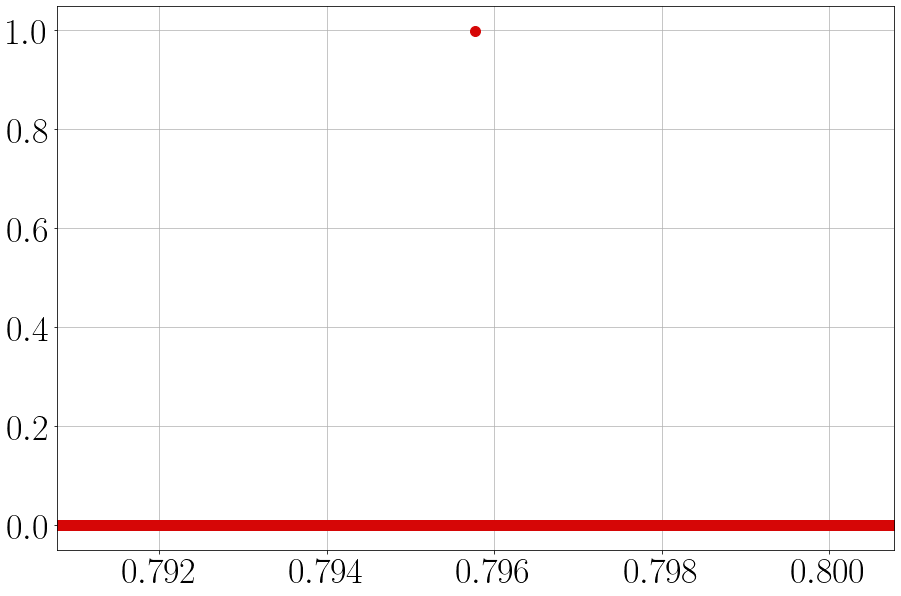

In [7]:
pl.plot(nufft_freq, nufft_power, 'o')
pl.xlim(f0/(2*np.pi)-0.005, f0/(2*np.pi)+0.005)

In [9]:
tic = time.time()
power_arr = []
f0_arr = []

nufft_type = 1
n_modes = [len(t_space)]
plan = finufft.Plan(nufft_type, n_modes)

for i in range(10):
    f0 = np.random.uniform(1, 20)
    Mc = 1e-1* 2e30
    beta = const*f0**(8/3)*Mc**(5/3)

    phi = phi_calc(t_space, beta, f0)
    f = f_calc(t_space, beta, f0)
    signal = np.exp(1j*phi)

    nufft_freq, nufft_power = nufft(signal, phi/f0, len(signal))
    power_arr.append(max(nufft_power))
    f0_arr.append(f0)
    
print(f"Time = {time.time()-tic}")

Time = 47.076146602630615


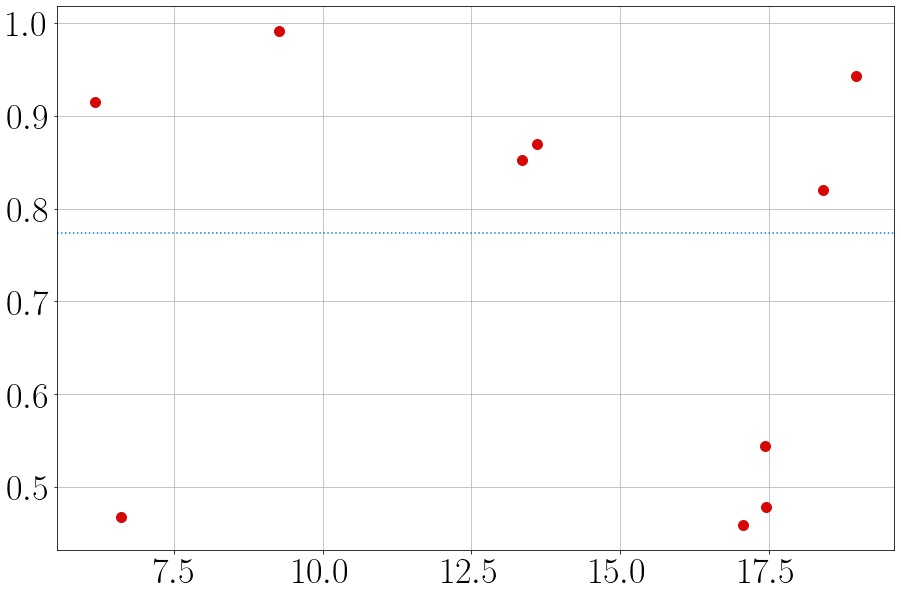

In [10]:
pl.plot(f0_arr, power_arr, 'o')
pl.axhline(2.4308/np.pi, c=blue, ls=':')

## Doppler

In [8]:
# pl.plot(t_space, f)
ephemeris = np.loadtxt("doppler/earth00-40-DE440.dat", delimiter = '\t', skiprows=18)
[t_eph, pos_x, pos_y, pos_z, vel_x, vel_y, vel_z, acc_x, acc_y, acc_z] = ephemeris.T

pos_arr = np.array([pos_x, pos_y, pos_z])
interp_pos = CubicSpline(t_eph, pos_arr.T)
v_arr = np.array([vel_x, vel_y, vel_z])
interp_v = CubicSpline(t_eph, v_arr.T)
acc_arr = np.array([acc_x, acc_y, acc_z])
interp_acc = CubicSpline(t_eph, acc_arr.T)

H_lat = 119.41 * np.pi/180 # rad
H_lng = 46.45 * np.pi/180 # rad

params = dict(ra = 0.5, dec = 0.5, eta = 0.5, psi = 0.5, lat = H_lat, 
              lng = H_lng, az = 0.5)

n_hat = (np.cos(params['ra'])*np.cos(params['dec']),
        np.sin(params['ra'])*np.cos(params['dec']),
        np.sin(params['dec']))

Sampling frequency = 1.1573958333333334


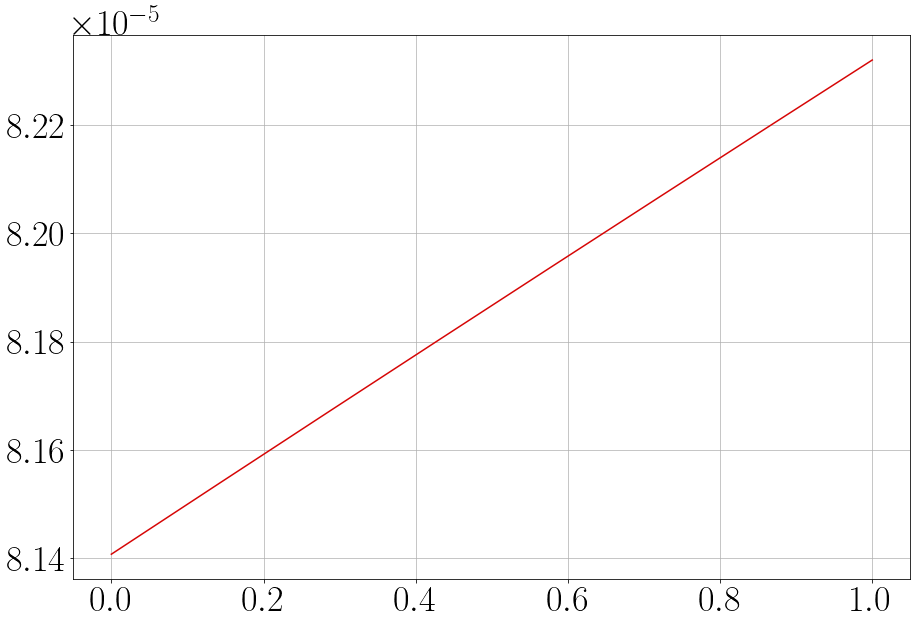

In [10]:
# Using t=30 days for long enough to see Doppler effects
day = 86400
duration = 1*day
start_time = t_eph[abs(t_eph-(t_eph[0]+24*365*day)).argmin()] # very approximately 1st Jan 2024
t_offset = np.linspace(0, duration, int(1e5))
t_doppler = start_time + t_offset
samp_freq = 1/(np.diff(t_offset)[0])
print(f"Sampling frequency = {samp_freq}")

f0 = 0.1
Mc = 1e-1* 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(t_offset, beta, f0)
phi_source = phi_calc(t_offset, beta, f0)
signal_source = np.exp(1j*phi_source)
f_doppler = f_source*(1+np.dot(interp_v(t_doppler), n_hat))
pl.plot(t_offset/day, ((f_source - f_doppler)/f_source)) #Check you can see the effects

In [12]:
3*day/1e5

2.592

In [13]:
df_source = df_calc(t_offset, beta, f0)
df_source -= df_source[0]
temp = integrate.cumulative_trapezoid(t_offset+np.dot(interp_pos(t_doppler), n_hat),x=t_offset, initial=0)
temp -= temp[1]
temp[0] = temp[1]
phi_doppler = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_offset)
phi_doppler -= phi_doppler[0]
phi_approx1 = 2*np.pi*f_source*(t_offset+np.dot(interp_pos(t_doppler), n_hat))
phi_approx1 -= phi_approx1[0]
phi_approx2 = 2*np.pi*f_source*(t_offset+np.dot(interp_pos(t_doppler), n_hat)) \
             - df_calc(t_offset, beta, f0)*temp
phi_approx2 -= phi_approx2[0]

1st order approximation error: 0.06378321305965073
2nd order approximation error: 0.05363164773007156


Text(0.5, 0, 'Time [s] (total is 3 days)')

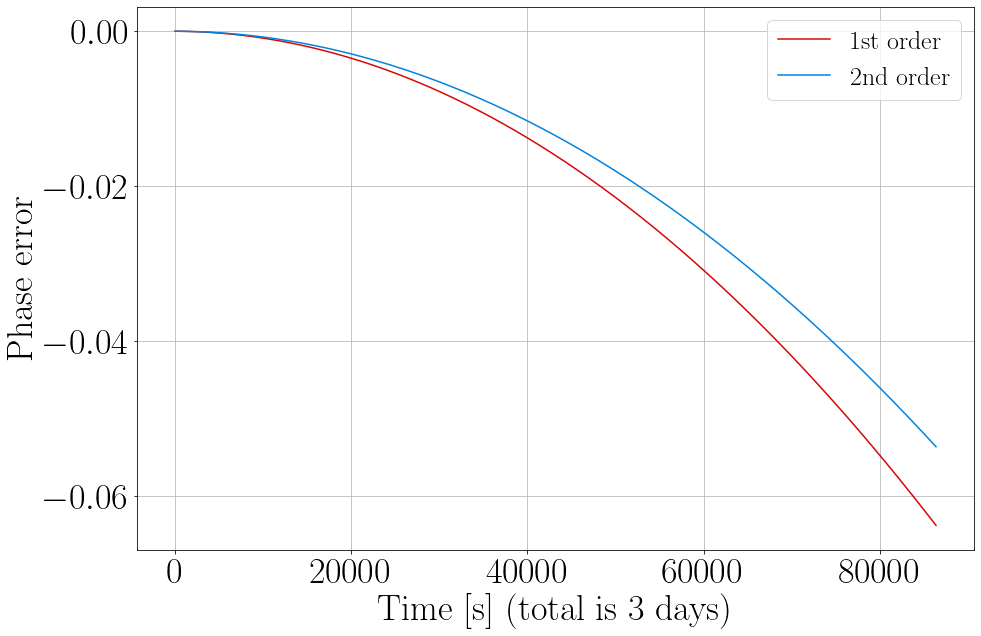

In [14]:
pl.plot(t_offset[:-1], phi_doppler-phi_approx1[:-1], label='1st order')
print(f"1st order approximation error: {max(abs(phi_doppler-phi_approx1[:-1]))}")

pl.plot(t_offset[:-1], phi_doppler-phi_approx2[:-1], label='2nd order')
print(f"2nd order approximation error: {max(abs(phi_doppler-phi_approx2[:-1]))}")
pl.legend()
pl.ylabel("Phase error")
pl.xlabel("Time [s] (total is 3 days)")
# pl.plot(phi_approx)

In [58]:
# CHecking robustment
error_arr = []
f_arr = []
beta_arr = []
N = 10

for i in range(N):
    f0 = np.random.uniform(0.1, 0.3)
    Mc = 1e-1* 2e30
    beta = const*f0**(8/3)*Mc**(5/3)
    f_arr.append(f0)
    beta_arr.append(beta)    
    
    f_source = f_calc(t_offset, beta, f0)
    phi_source = phi_calc(t_offset, beta, f0)
    signal_source = np.exp(1j*phi_source)
    f_doppler = f_source*(1+np.dot(interp_v(t_doppler), n_hat))

    df_source = df_calc(t_offset, beta, f0)
    df_source -= df_source[0]
    temp = integrate.cumulative_trapezoid(t_offset+np.dot(interp_pos(t_doppler), n_hat),x=t_offset, initial=0)
    temp -= temp[1]
    temp[0] = temp[1]
    phi_doppler = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_offset)
    phi_doppler -= phi_doppler[0]
    phi_approx = 2*np.pi*f_source*(t_offset+np.dot(interp_pos(t_doppler), n_hat)) \
                 - df_calc(t_offset, beta, f0)*temp
    phi_approx -= phi_approx[0]
    max_err = max(abs(phi_doppler-phi_approx[:-1]))
    error_arr.append(max_err)

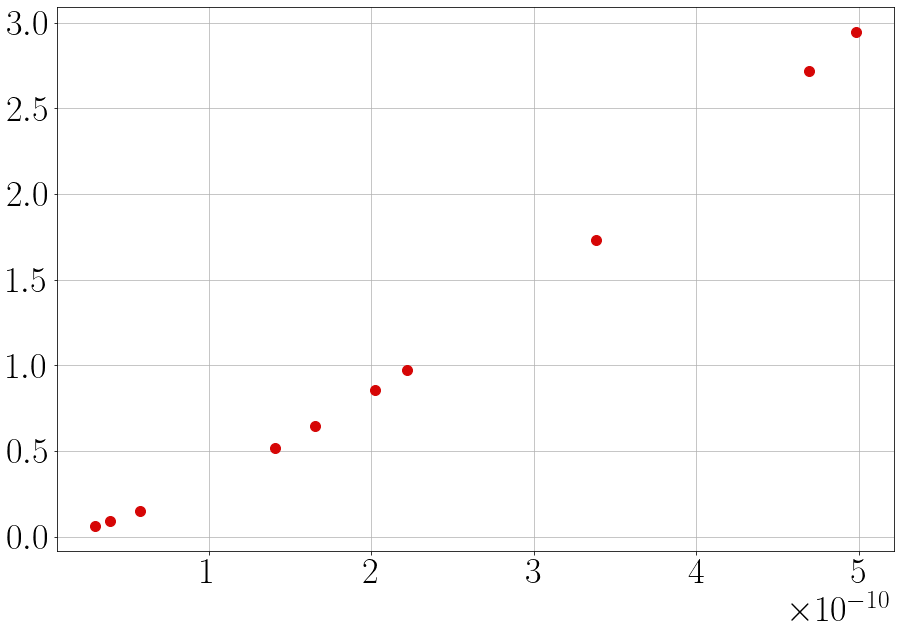

In [59]:
pl.plot(beta_arr, error_arr, 'o')

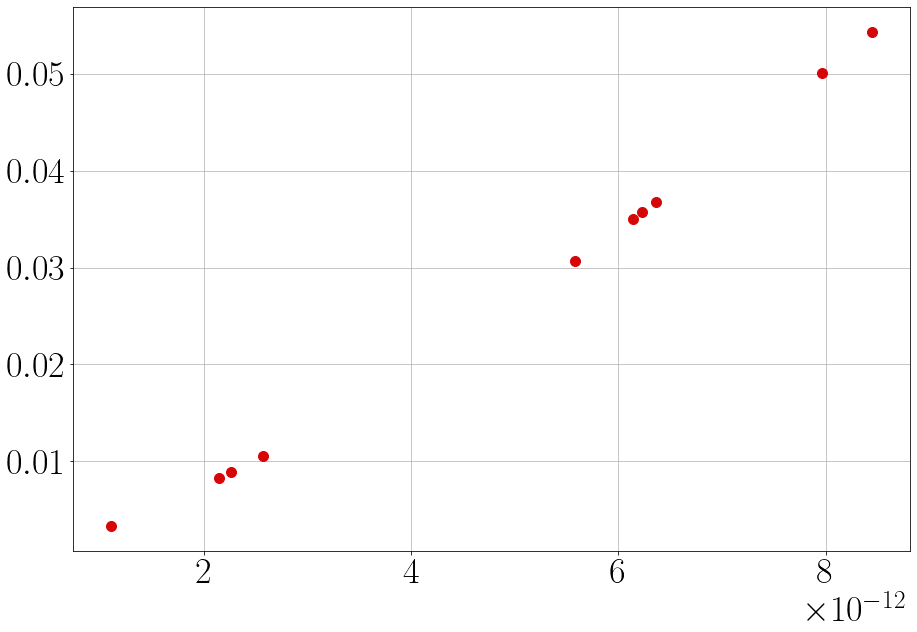

In [17]:
pl.plot(beta_arr, error_arr, 'o')

In [49]:
def beta_to_f0(beta, Mc):
    return const**(-3/8)*beta**(3/8)*Mc**(-5/8)

In [132]:
# Just depends on beta?

f0 = 0.3
Mc = 1e-1 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)

f_source = f_calc(t_offset, beta, f0)
phi_source = phi_calc(t_offset, beta, f0)
signal_source = np.exp(1j*phi_source)
f_doppler = f_source*(1+np.dot(interp_v(t_doppler), n_hat))

df_source = df_calc(t_offset, beta, f0)
df_source -= df_source[0]
temp = integrate.cumulative_trapezoid(t_offset+np.dot(interp_pos(t_doppler), n_hat),x=t_offset, initial=0)
temp -= temp[1]
temp[0] = temp[1]
phi_doppler = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_offset)
phi_doppler -= phi_doppler[0]
phi_approx = 2*np.pi*f_source*(t_offset+np.dot(interp_pos(t_doppler), n_hat)) \
             - df_calc(t_offset, beta, f0)*temp
phi_approx -= phi_approx[0]
max_err = max(abs(phi_doppler-phi_approx[:-1]))

In [133]:
Mc_new = 7e-2*2e30
f_new = beta_to_f0(beta, Mc_new)
print(np.isclose(beta, const*f_new**(8/3)*Mc_new**(5/3), atol=0, rtol=1e-4))

f_source_new = f_calc(t_offset, beta, f_new)
phi_source_new = phi_calc(t_offset, beta, f_new)
signal_source_new = np.exp(1j*phi_source_new)
f_doppler_new = f_source_new*(1+np.dot(interp_v(t_doppler), n_hat))

df_source_new = df_calc(t_offset, beta, f_new)
df_source_new -= df_source_new[0]
temp_new = integrate.cumulative_trapezoid(t_offset+np.dot(interp_pos(t_doppler), n_hat),x=t_offset, initial=0)
temp_new -= temp_new[1]
temp_new[0] = temp_new[1]
phi_doppler_new = 2*np.pi*integrate.cumulative_trapezoid(f_doppler_new, x=t_offset)
phi_doppler_new -= phi_doppler_new[0]
phi_approx_new = 2*np.pi*f_source_new*(t_offset+np.dot(interp_pos(t_doppler), n_hat)) \
             - df_calc(t_offset, beta, f_new)*temp_new
phi_approx_new -= phi_approx_new[0]
max_err_new = max(abs(phi_doppler_new-phi_approx_new[:-1]))

print(max_err-max_err_new)
# Conclusion, the error does not only depend on beta

True
-0.7522462432389148


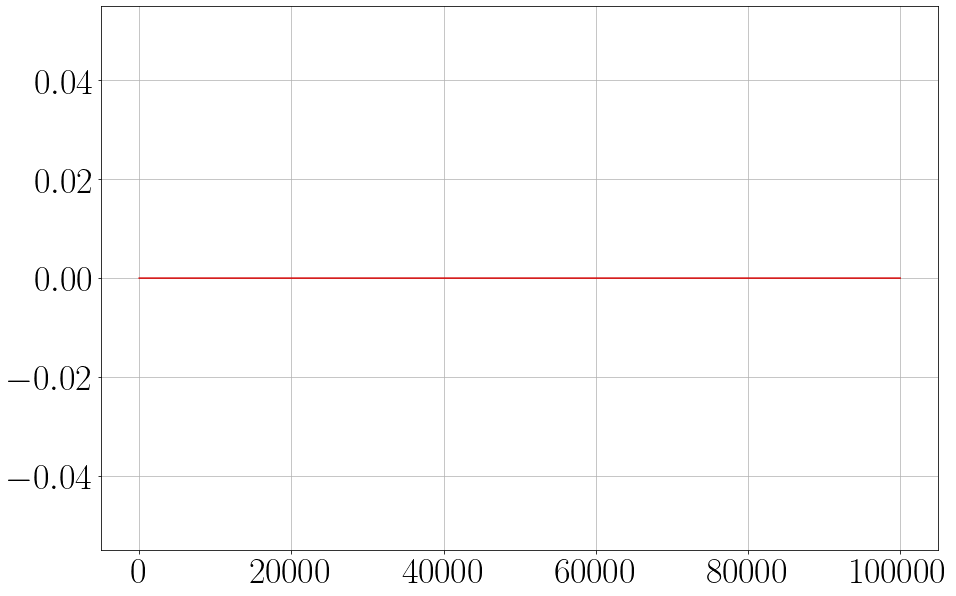

In [134]:
temp0 = 2*np.pi*f_source_new*(t_offset+np.dot(interp_pos(t_doppler), n_hat))/f_new
temp1 = 2*np.pi*f_source*(t_offset+np.dot(interp_pos(t_doppler), n_hat))/f0
pl.plot(temp_new-temp)

Text(0.5, 0, 'Time [s]')

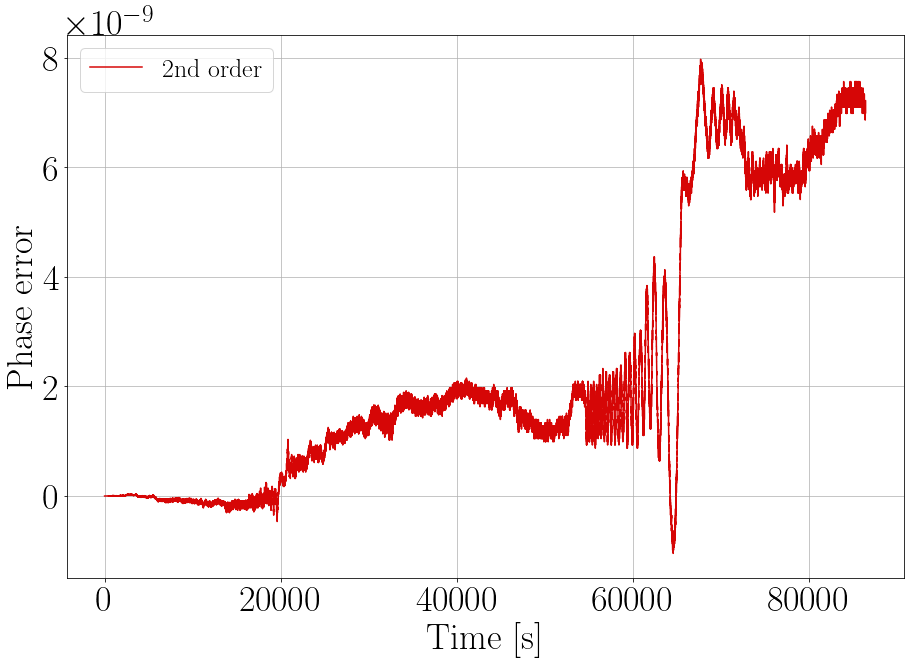

In [135]:
pl.plot(t_offset[:-1], (phi_doppler)/f0 - (phi_doppler_new)/f_new, label='2nd order')
pl.legend()
pl.ylabel("Phase error")
pl.xlabel("Time [s]")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0, 'Time [s]')

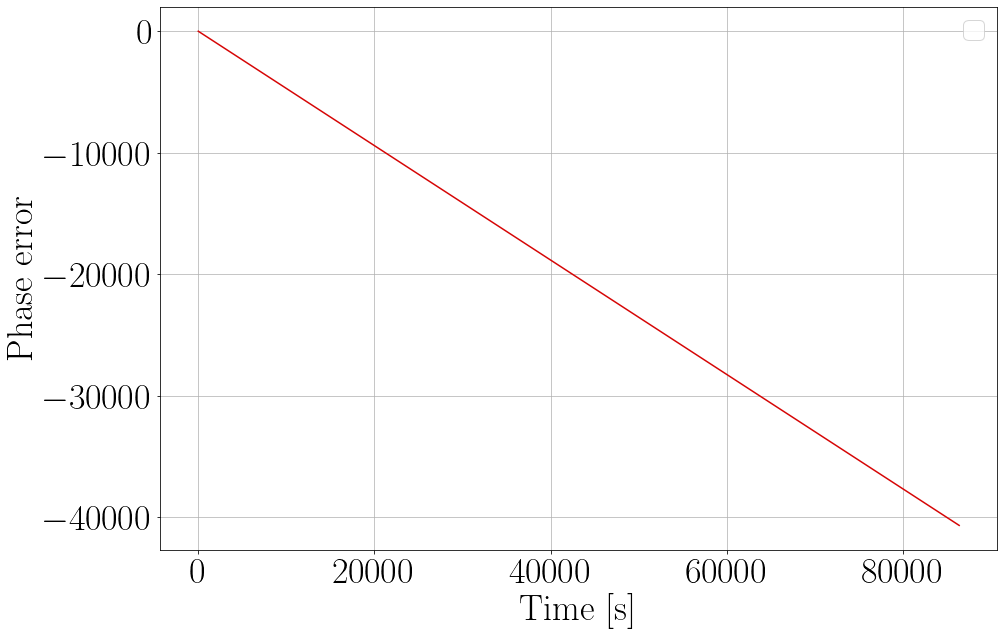

In [98]:
pl.plot(t_offset[:-1], phi_doppler-phi_doppler_new)
pl.legend()
pl.ylabel("Phase error")
pl.xlabel("Time [s]")

## Trying to approximate higher order terms (>2nd order)

In [6]:
def ddf_calc(t, beta, f0):
    return 11/3*f0*beta**2*(1-8/3*beta*t)**(-19/8)

In [13]:
pl.plot(temp* ddf_calc(t_offset, 10**(-5), 20))

NameError: name 'temp' is not defined

/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in power
  


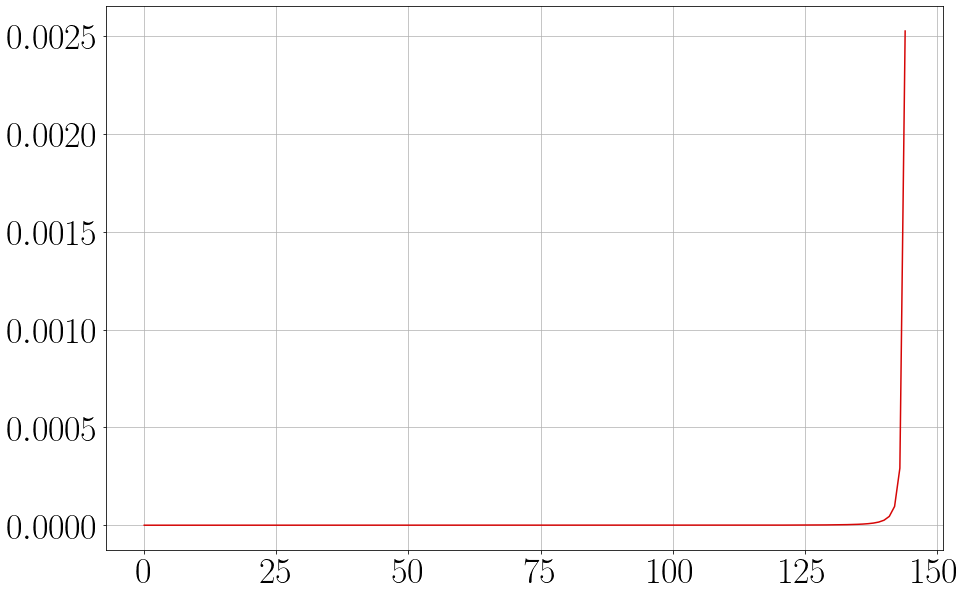

In [14]:
pl.plot(ddf_calc(t_offset, 1e-5, 20))

### Each higher order term scales as $\beta^n t^n$?

If we ignore the oscillatory component from Doppler

If true then given a fixed time window (say 3 days ~ 1e5s), then method would work for $\beta^{-1} > t$. Most (but not all of the parameter space gives $\beta > 10^{-5}$

1.7169895555741805e-08
1.0714446596696796e-07


/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in power
  
/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in power
  


Text(0.5, 0, 'Time [days]')

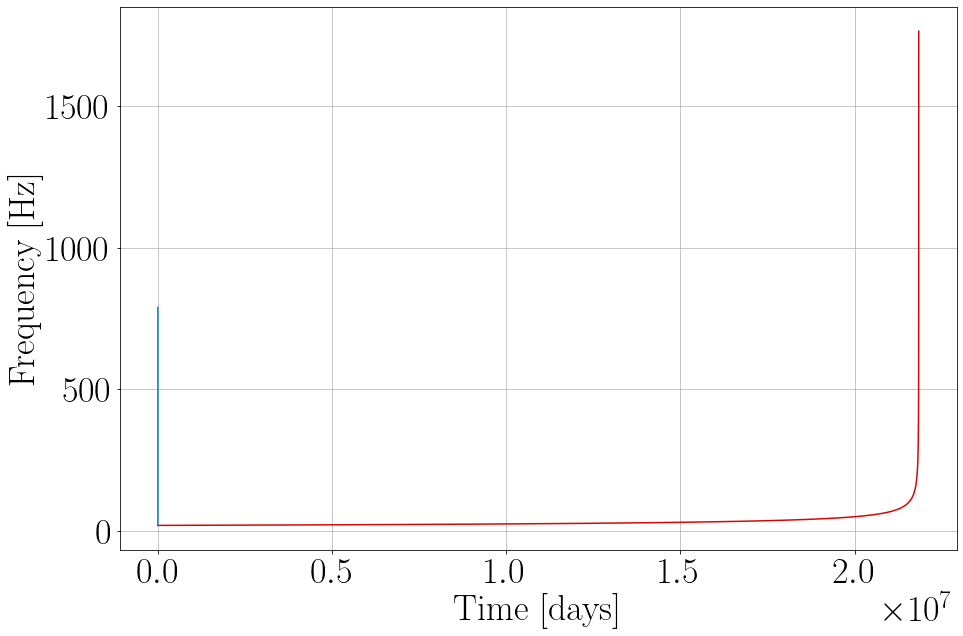

In [12]:
duration = 300*day
t_offset = np.linspace(0, duration, int(1e5))

f0 = 20
Mc = 1e-3* 2e30
beta = const*f0**(8/3)*Mc**(5/3)
print(beta)

pl.plot(t_offset, f_calc(t_offset, beta, f0))

f0 = 20
Mc = 3e-3* 2e30
beta = const*f0**(8/3)*Mc**(5/3)
print(beta)

pl.plot(t_offset/day, f_calc(t_offset, beta, f0))
pl.ylabel("Frequency [Hz]")
pl.xlabel("Time [days]")

## Can we just numerically integrate?

In [109]:
f0 = np.random.uniform(0.1, 0.3)
Mc = 1e-2* 2e30
beta = const*f0**(8/3)*Mc**(5/3)
f_source = f_calc(t_offset, beta, f0)
phi_source = phi_calc(t_offset, beta, f0)
signal_source = np.exp(1j*phi_source)
f_doppler = f_source*(1+np.dot(interp_v(t_doppler), n_hat))

phi_doppler = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_offset)
phi_doppler -= phi_doppler[0]
signal_doppler = np.exp(1j*phi_doppler)

In [110]:
Mc_new = 2e-2*2e30
f_new = beta_to_f0(beta, Mc_new)

f_source_new = f_calc(t_offset, beta, f_new)
phi_source_new = phi_calc(t_offset, beta, f_new)
signal_source_new = np.exp(1j*phi_source_new)
f_doppler_new = f_source_new*(1+np.dot(interp_v(t_doppler), n_hat))

# df_source_new = df_calc(t_offset, beta, f_new)
# df_source_new -= df_source_new[0]
# temp_new = integrate.cumulative_trapezoid(t_offset+np.dot(interp_pos(t_doppler), n_hat),x=t_offset, initial=0)
# temp_new -= temp_new[1]
# temp_new[0] = temp_new[1]
phi_doppler_new = 2*np.pi*integrate.cumulative_trapezoid(f_doppler_new, x=t_offset)
phi_doppler_new -= phi_doppler_new[0]
# phi_approx_new = 2*np.pi*f_source_new*(t_offset+np.dot(interp_pos(t_doppler), n_hat)) \
#              - df_calc(t_offset, beta, f0)*temp
# phi_approx_new -= phi_approx_new[0]
# max_err_new = max(abs(phi_doppler_new-phi_approx_new[:-1]))

# print(max_err-max_err_new)

In [111]:
test0 = 2*np.pi*integrate.cumulative_trapezoid(f_doppler/f0, x=t_offset)
test1 = 2*np.pi*integrate.cumulative_trapezoid(f_doppler_new/f_new, x=t_offset)

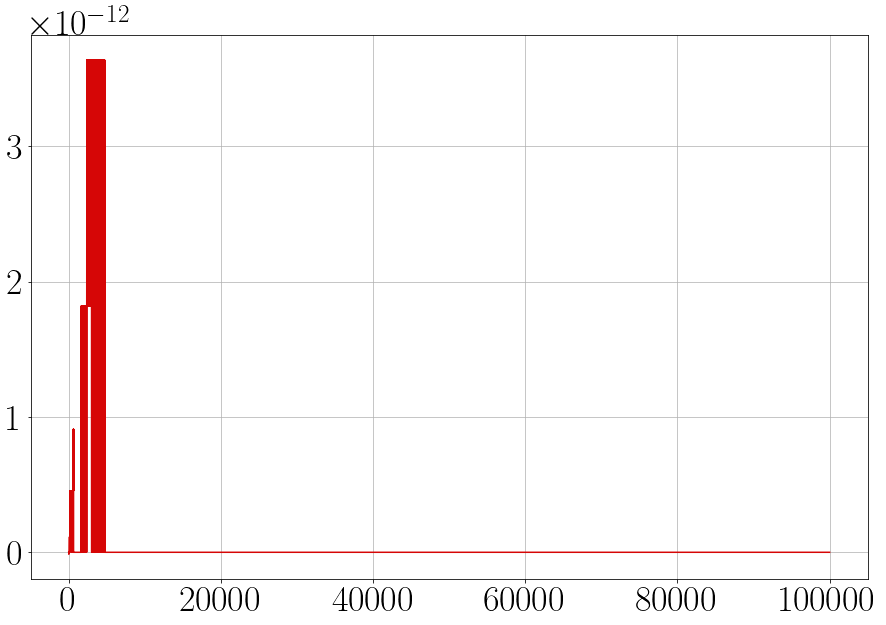

In [113]:
pl.plot(test0-test1)

(0.024259405289639737, 0.034259405289639736)

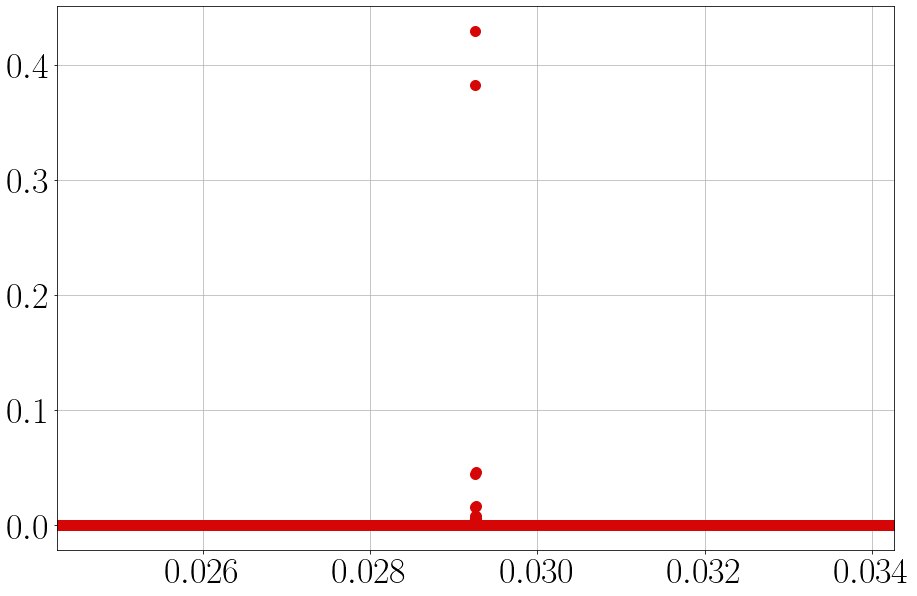

In [27]:
nufft_freq, nufft_power = nufft(signal_doppler, phi_doppler/f0, len(signal))
pl.plot(nufft_freq, nufft_power, 'o')
pl.xlim(f0/(2*np.pi)-0.005, f0/(2*np.pi)+0.005)